# Live Coding Bab 5 — Algoritma Klasifikasi Random Forest

Nama : Hassan Nashrallah

NIM  : 245150200111025

### **Random Forest Classifier Algorithm**

Algoritma Random Forest Classifier adalah algoritma pembelajaran mesin populer yang dikembangkan oleh Leo Breiman dan Adele Cutler. Algoritma ini menggabungkan output dari beberapa pohon keputusan untuk mendapatkan satu hasil, sehingga membuatnya serbaguna untuk masalah klasifikasi dan regresi.

#### **1. Hyperparameter**
Hyperparameter utama yang digunakan pada algoritma random forest ini adalah:
*   **shuffle: Randomize decision (keputusan pengacakan data)**
*   **n_estimators: Number of trees (jumlah pohon keputusan)**
*   **random_state: Randomize data (pengacakan data)**
*   **n_splits: Folds number (jumlah lipatan cross-validation)**

#### **2. Decision Tree**

Pohon keputusan dari algoritma ini dimulai dengan pertanyaan dasar dan bercabang dengan lebih banyak pertanyaan (decision nodes) untuk mencapai keputusan akhir (leaf node). Pohon-pohon keputusan ini dilatih menggunakan algoritma Classification and Regression Tree (CART) dan mengevaluasi pemisahan berdasarkan metrik seperti Gini impurity, information gain, atau mean square error. Meskipun efektif, pohon keputusan dapat mengalami bias dan overfitting.

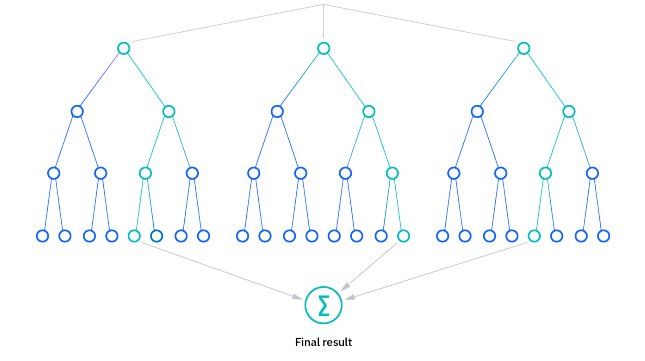


#### **3. Ensemble Method**

Metode pembelajaran ensemble, seperti bagging dan boosting, menggunakan beberapa pengklasifikasi untuk menggabungkan prediksi untuk hasil yang lebih akurat. Bagging, yang diperkenalkan oleh Leo Breiman pada tahun 1996, melibatkan pembuatan beberapa sampel data dengan penggantian dan pelatihan model secara independen pada sampel-sampel ini. Pendekatan ini mengurangi varians dan meningkatkan akurasi.

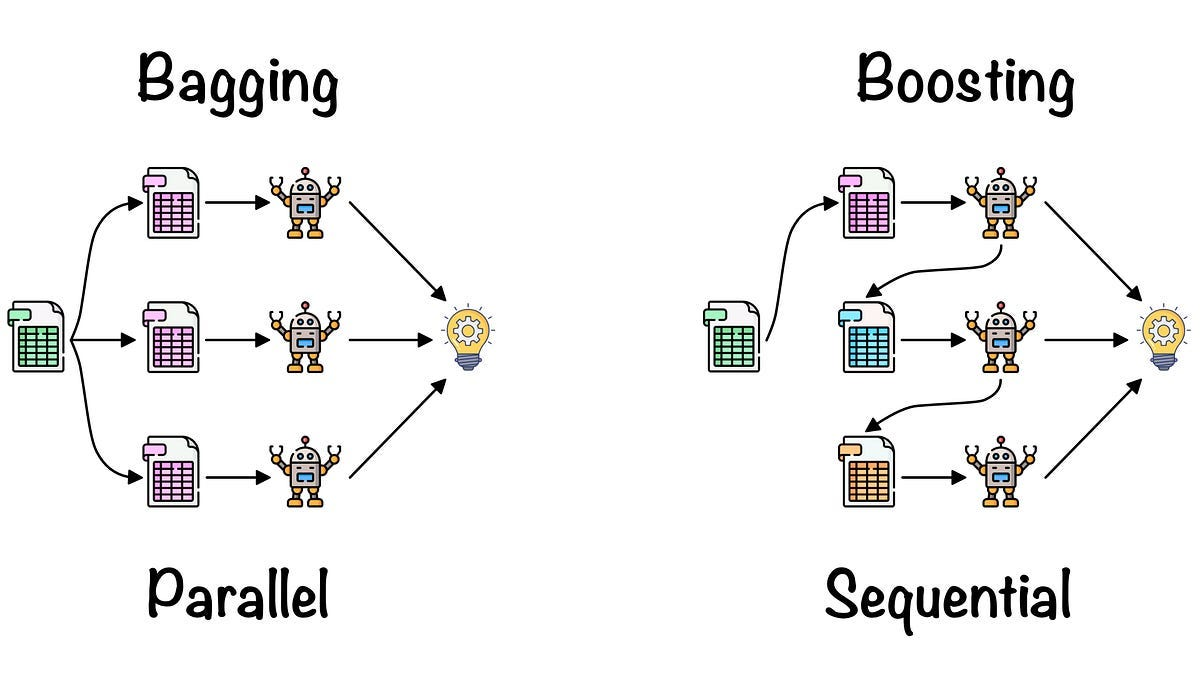

#### **4. Algoritma Random Forest**

Algoritma random forest memperluas bagging dengan menambahkan keacakan fitur, memastikan korelasi yang rendah di antara pohon-pohon keputusan. Setiap pohon di dalam hutan dilatih dengan sampel bootstrap dari data pelatihan, dan subset fitur acak digunakan untuk memisahkan node. Hal ini mengurangi overfitting, bias, dan varians, sehingga menghasilkan prediksi yang lebih tepat.

Random forest classifier dapat menangani tugas regresi dan klasifikasi. Untuk regresi, ia menggunakan rata-rata prediksi dari masing-masing pohon, sedangkan untuk klasifikasi, ia menggunakan suara mayoritas. Selain itu, sampel di luar kantong (out-of-bag (oob)) digunakan untuk validasi silang, sehingga meningkatkan keandalan model.


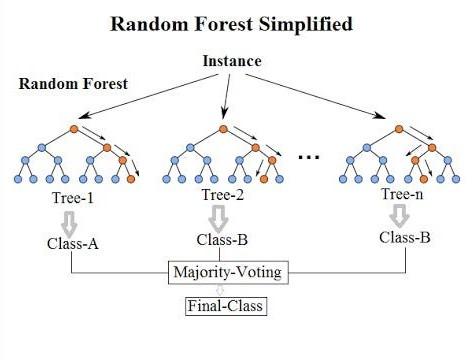

---
## Langkah 1: Import Library & Load Dataset

In [1]:
# Instalasi dan import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Library Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
# TODO: Load dataset Titanic menggunakan seaborn
# Hint: sns.load_dataset("...")

data = sns.load_dataset("titanic")

In [3]:
# TODO: Tampilkan 5 baris pertama dataset
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Langkah 2: Eksplorasi Data (EDA)

In [4]:
# TODO: Tampilkan informasi tipe data setiap kolom menggunakan .info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# TODO: Tampilkan statistik deskriptif dataset menggunakan .describe()
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


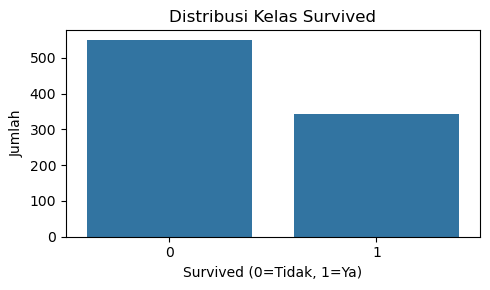

In [6]:
# TODO: Cek distribusi kelas target 'survived' menggunakan countplot
# Hint: sns.countplot(x=..., data=...)
plt.figure(figsize=(5, 3))
sns.countplot(x='survived', data=data)
plt.title("Distribusi Kelas Survived")
plt.xlabel("Survived (0=Tidak, 1=Ya)")
plt.ylabel("Jumlah")
plt.tight_layout()
plt.show()

In [7]:
# TODO: Hitung jumlah nilai unik setiap kolom
# Hint: .nunique()
print("Jumlah nilai unik per kolom:")
print(data.nunique())

Jumlah nilai unik per kolom:
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


In [8]:
# TODO: Cek jumlah missing values setiap kolom
# Hint: .isnull().sum()
print("Missing values per kolom:")
print(data.isnull().sum())

Missing values per kolom:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


---
## Langkah 3: Preprocessing Data

In [9]:
# TODO: Hapus kolom yang tidak relevan atau terlalu banyak missing values
# Kolom yang dihapus: 'deck', 'embark_town', 'alive', 'class',
#                     'who', 'adult_male', 'alone', 'embarked'
# Hint: data.drop(columns=[...], inplace=True)
kolom_hapus = ['deck', 'embark_town', 'alive', 'class',
               'who', 'adult_male', 'alone', 'embarked']
data.drop(columns=kolom_hapus, inplace=True)
print("Kolom setelah dihapus:", list(data.columns))

Kolom setelah dihapus: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']


In [10]:
# TODO: Isi missing values kolom 'age' dengan nilai MEDIAN
# Hint: data['age'].fillna(..., inplace=True)

data['age'].fillna(data['age'].median(), inplace=True)

print("Missing values setelah imputasi:")
print(data.isnull().sum())

Missing values setelah imputasi:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
dtype: int64


C:\Users\hassa\AppData\Local\Temp\ipykernel_32624\1841730192.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)


In [11]:
# TODO: Lengkapi proses One-Hot Encoding untuk kolom kategori 'sex'
# Hint: drop='first' untuk menghindari multikolinearitas

categorical_features = ['sex']

# TODO: Buat objek OneHotEncoder dengan drop='first' dan sparse_output=False
encoder = OneHotEncoder(drop='first', sparse_output=False)

# TODO: Fit dan transform kolom kategori
categorical_encoded = encoder.fit_transform(data[categorical_features])

# TODO: Buat DataFrame hasil encoding dengan nama kolom dari encoder
categorical_data = pd.DataFrame(
    categorical_encoded,
    columns=encoder.get_feature_names_out(categorical_features)
)

print("Hasil encoding:")
print(categorical_data.head())

Hasil encoding:
   sex_male
0       1.0
1       0.0
2       0.0
3       0.0
4       1.0


In [12]:
# TODO: Gabungkan hasil encoding dengan data utama lalu hapus kolom 'sex' asli
# Hint: pd.concat([data, categorical_data], axis=1)
data = pd.concat([data, categorical_data], axis=1)
data = data.drop(columns='sex')

print("Kolom setelah encoding:", list(data.columns))

Kolom setelah encoding: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']


In [13]:
# TODO: Pisahkan fitur (X) dan target (y)
# Fitur: semua kolom kecuali 'survived'
# Target: kolom 'survived'
X = data[['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male']]
y = data['survived']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (891, 6)
Shape y: (891,)


In [14]:
# TODO: Split data menjadi train dan test dengan rasio 80:20
# Gunakan random_state=42
# Hint: train_test_split(X, y, test_size=..., random_state=...)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

print("Ukuran data latih :", X_train.shape)
print("Ukuran data uji   :", X_test.shape)

Ukuran data latih : (712, 6)
Ukuran data uji   : (179, 6)


In [15]:
# TODO: Standarisasi fitur numerik menggunakan StandardScaler
# Hint: fit pada X_train, transform pada X_train dan X_test

scaler  = StandardScaler()

# TODO: Fit scaler pada data latih lalu transform data latih
X_train = scaler.fit_transform(X_train)

# TODO: Transform saja pada data uji (jangan fit lagi!)
X_test  = scaler.transform(X_test)

print("Standarisasi selesai.")

Standarisasi selesai.


---
## Langkah 4: Training Model Random Forest

In [16]:
# TODO: Lengkapi pembuatan dan pelatihan model Random Forest
# Parameter:
#   - n_estimators  : jumlah pohon = 100
#   - random_state  : 42
#   - n_jobs        : -1  (gunakan semua core)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# TODO: Latih model menggunakan data latih
# Hint: rf_model.fit(..., ...)
rf_model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


In [17]:
# TODO: Lakukan prediksi pada data uji menggunakan model yang sudah dilatih
# Hint: rf_model.predict(...)
y_pred = rf_model.predict(X_test)

# TODO: Prediksi probabilitas untuk ROC-AUC
# Hint: rf_model.predict_proba(...)[:, 1]  -> ambil probabilitas kelas positif
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Prediksi selesai.")
print("Contoh 5 prediksi pertama:", y_pred[:5])

Prediksi selesai.
Contoh 5 prediksi pertama: [0 0 0 1 0]


---
## Langkah 5: Visualisasi Data

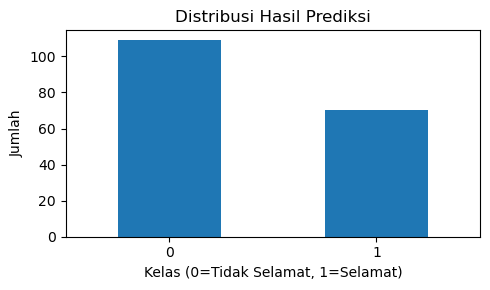

Jumlah tiap kelas prediksi:
0    109
1     70
Name: count, dtype: int64


In [18]:
# TODO: Visualisasi distribusi kelas target (survived) pada data uji
# Buat bar plot yang menampilkan jumlah prediksi tiap kelas

plt.figure(figsize=(5, 3))

# TODO: Hitung jumlah tiap kelas pada y_pred lalu plot
# Hint: pd.Series(y_pred).value_counts().sort_index().plot(kind='bar')
pd.Series(y_pred).value_counts().sort_index().plot(kind='bar')

plt.title("Distribusi Hasil Prediksi")
plt.xlabel("Kelas (0=Tidak Selamat, 1=Selamat)")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# TODO: Cetak jumlah tiap kelas dalam bentuk angka
print("Jumlah tiap kelas prediksi:")
print(pd.Series(y_pred).value_counts())

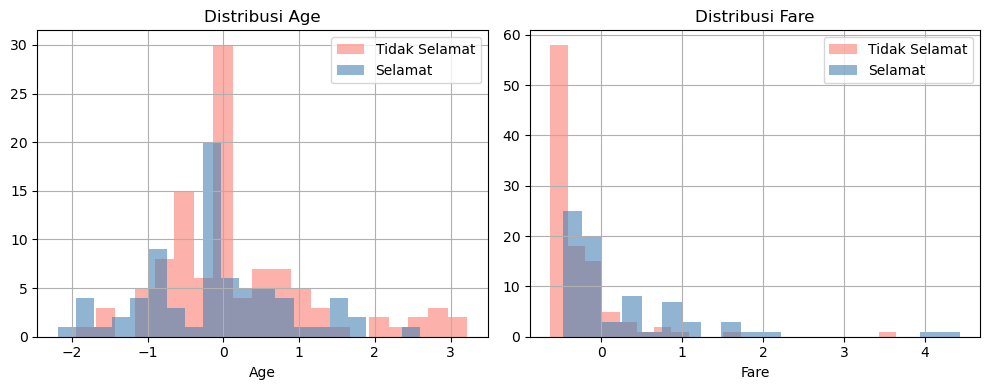

In [19]:
# TODO: Visualisasi distribusi fitur 'age' dan 'fare' berdasarkan target asli (y_test)
# Buat 2 subplot histogram side-by-side

# Buat DataFrame sementara dari X_test agar bisa diakses kolom-kolomnya
X_test_df = pd.DataFrame(X_test,
                          columns=X.columns)
X_test_df['survived'] = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# TODO: Plot histogram 'age' dikelompokkan berdasarkan 'survived'
# Hint: X_test_df[X_test_df['survived']==0]['age'].hist(...)
for kelas, warna, label in zip([0, 1], ['salmon', 'steelblue'],
                                ['Tidak Selamat', 'Selamat']):
    X_test_df[X_test_df['survived'] == kelas]['age'].hist(
        ax=axes[0], alpha=0.6, color=warna, label=label, bins=20
    )
axes[0].set_title("Distribusi Age")
axes[0].set_xlabel("Age")
axes[0].legend()

# TODO: Plot histogram 'fare' dikelompokkan berdasarkan 'survived'
for kelas, warna, label in zip([0, 1], ['salmon', 'steelblue'],
                                ['Tidak Selamat', 'Selamat']):
    X_test_df[X_test_df['survived'] == kelas]['fare'].hist(
        ax=axes[1], alpha=0.6, color=warna, label=label, bins=20
    )
axes[1].set_title("Distribusi Fare")
axes[1].set_xlabel("Fare")
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Langkah 6: Evaluasi Model

In [20]:
# TODO: Hitung dan cetak akurasi model
# Hint: accuracy_score(y_test, y_pred)
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Random Forest: {akurasi}")

Akurasi Model Random Forest: 0.8100558659217877


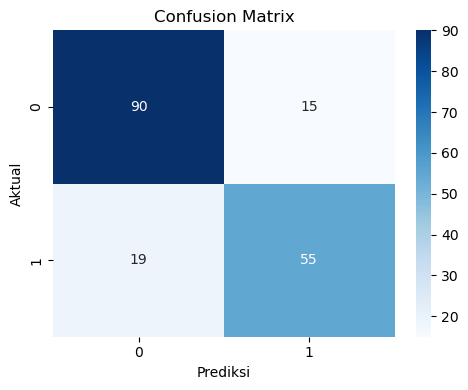

TP=55  TN=90  FP=15  FN=19


In [21]:
# TODO: Lengkapi fungsi plot_confusion_matrix di bawah ini

def plot_confusion_matrix(y_true, y_pred, judul='Confusion Matrix'):
    """
    Menghitung dan memvisualisasikan confusion matrix.

    Parameter:
        y_true : array label sebenarnya
        y_pred : array label prediksi
        judul  : judul plot
    """
    # TODO: Hitung confusion matrix menggunakan confusion_matrix()
    cm = confusion_matrix(y_true, y_pred)

    # TODO: Buat heatmap confusion matrix menggunakan sns.heatmap()
    # Hint: annot=True, fmt='d', cmap='Blues'
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(judul)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

    # TODO: Cetak nilai TP, TN, FP, FN dari confusion matrix
    # Hint: TN = cm[0,0], FP = cm[0,1], FN = cm[1,0], TP = cm[1,1]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    print(f"TP={TP}  TN={TN}  FP={FP}  FN={FN}")

# Panggil fungsi
plot_confusion_matrix(y_test, y_pred)

In [22]:
# TODO: Cetak classification report lengkap
# Hint: classification_report(y_test, y_pred, target_names=[...])
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Tidak Selamat', 'Selamat']))

Classification Report:
               precision    recall  f1-score   support

Tidak Selamat       0.83      0.86      0.84       105
      Selamat       0.79      0.74      0.76        74

     accuracy                           0.81       179
    macro avg       0.81      0.80      0.80       179
 weighted avg       0.81      0.81      0.81       179



<Figure size 700x400 with 0 Axes>

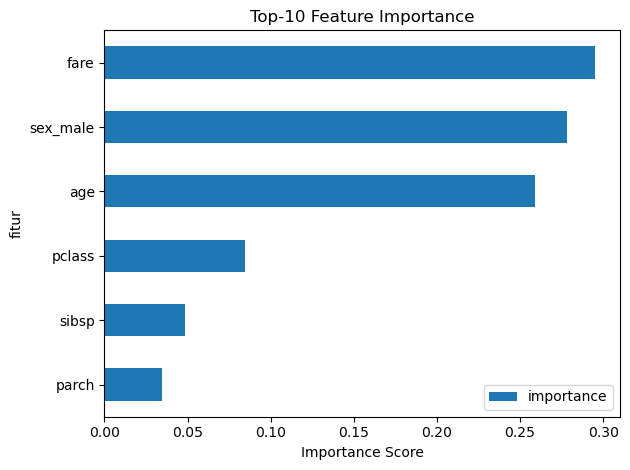

   fitur  importance
    fare    0.295317
sex_male    0.278384
     age    0.258944
  pclass    0.084364
   sibsp    0.048445
   parch    0.034545


In [23]:
# TODO: Lengkapi fungsi analisis feature importance di bawah ini

def plot_feature_importance(model, feature_names, top_n=10):
    """
    Menampilkan top-N fitur paling penting dari model Random Forest.

    Parameter:
        model         : model RandomForest yang sudah dilatih
        feature_names : nama-nama kolom fitur
        top_n         : jumlah fitur teratas yang ditampilkan
    """
    # TODO: Ambil nilai feature importance dari model
    # Hint: model.feature_importances_
    importances = model.feature_importances_

    # TODO: Buat DataFrame dari feature_names dan importances
    # lalu urutkan dari yang terbesar (ascending=False)
    df_importance = pd.DataFrame({
        'fitur'      : feature_names,
        'importance' : importances
    }).sort_values('importance', ascending=False)

    # TODO: Ambil top_n fitur teratas
    df_top = df_importance.head(top_n)

    # TODO: Plot horizontal bar chart
    # Hint: df_top.plot(kind='barh', x='fitur', y='importance')
    plt.figure(figsize=(7, 4))
    df_top.plot(kind='barh', x='fitur', y='importance')
    plt.title(f"Top-{top_n} Feature Importance")
    plt.xlabel("Importance Score")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print(df_top.to_string(index=False))

# Panggil fungsi
plot_feature_importance(rf_model, X.columns)

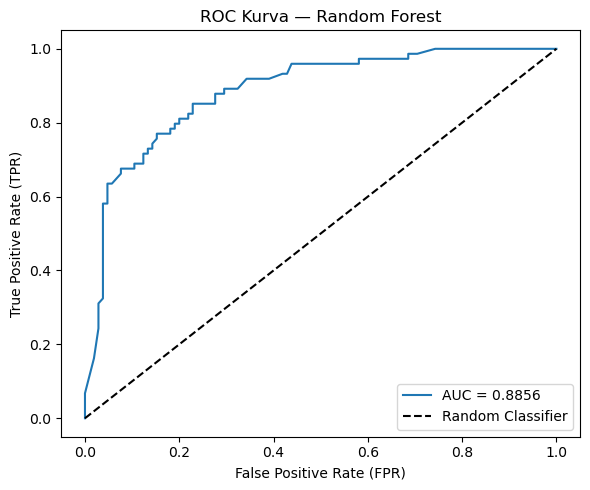

ROC-AUC Score: 0.8856


In [24]:
# TODO: Lengkapi fungsi hitung dan plot ROC-AUC di bawah ini

def plot_roc_auc(y_true, y_prob):
    """
    Menghitung ROC-AUC Score dan menampilkan kurva ROC.

    Parameter:
        y_true : label sebenarnya
        y_prob : probabilitas prediksi kelas positif
    """
    from sklearn.metrics import roc_curve

    # TODO: Hitung ROC-AUC Score
    # Hint: roc_auc_score(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)

    # TODO: Hitung nilai FPR, TPR, dan threshold untuk kurva ROC
    # Hint: roc_curve(y_true, y_prob)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    # TODO: Plot kurva ROC
    # Hint: plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")

    # Garis diagonal (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Kurva — Random Forest')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"ROC-AUC Score: {auc_score:.4f}")

# Panggil fungsi
plot_roc_auc(y_test, y_prob)

---
## Ringkasan Hasil Evaluasi

In [25]:
# Cell ini sudah lengkap — jalankan setelah semua TODO selesai
print(f"  Akurasi   : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")
print(f"  Jumlah pohon (n_estimators): {rf_model.n_estimators}")
print(f"  Fitur terpenting: {X.columns[rf_model.feature_importances_.argmax()]}")

  Akurasi   : 81.01%
  ROC-AUC   : 0.8856
  Jumlah pohon (n_estimators): 100
  Fitur terpenting: fare


---
## Kesimpulan

> 1. Apakah tujuan percobaan berhasil dicapai?
> 2. Bagaimana performa model (akurasi & AUC) yang diperoleh?
> 3. Fitur apa yang paling berpengaruh dalam prediksi? Mengapa?

1. Iya, tujuan percobaan berhasil dicapai.
2. Model tersebut mendapatkan skor akurasi sebesar 81.01%. Selain itu, model tersebut juga mendapatkan skor ROC-AUC sebesar 0.8856 atau 88.56%, yang mana tergolong baik karena mendekati 1. Secara keseluruhan, model tersebut memiliki performa yang baik dan cukup kuat, terutama dari skor ROC-AUC yang tinggi. Hal ini menunjukkan bahwa model tidak hanya akurat, tetapi juga bagus dalam membedakan kelas positif dan negatif.
3. Berdasarkan hasil dari chart feature importances, fitur "fare" adalah fitur yang paling berpengaruh dalam prediksi survival, karena fare (harga tiket) berkorelasi dengan kelas sosial (Pclass). Semakin tinggi kelas tiket penumpang, penumpang lebih  lebih mudah mengakses perahu keselamatan dan dapat dievakuasi lebih dulu.